# Descriptives: plot certification counts for BL, EL, for bronze/silver/gold
This notebook creates a figure showing certification in BL and EL for each of the different certification categories.
It creates 2 versions:
    - counts
    - percentages

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory
from pathlib import Path
import sys

CODE_ROOT = Path.cwd().parents[1]
sys.path.append(str(CODE_ROOT))
import config

# Global plotting font
plt.rcParams["font.family"] = "Arial"

In [2]:
# Load data
labs = pd.read_csv(
    config.PROCESSED_DATA / "individual_processed_4.csv",
    keep_default_na=False,  # Keep "None" as a string, not NaN
    na_values=[""] # Only treat empty strings as NaN
)
equipment = pd.read_csv(
    config.PROCESSED_DATA / "panel_processed_2.csv",
    keep_default_na=False,  # Keep "None" as a string, not NaN
    na_values=[""] # Only treat empty strings as NaN
)

In [3]:
# Check for sensitivity
print("Sensitivity checks")
print("Number of labs by bronze, silver, gold certification in BL and EL")
for s in ["bl", "el"]:
    for award in ["bronze", "silver", "gold"]:
        print(labs[f"{award}_cert_{s}"].value_counts(dropna=True))

Sensitivity checks
Number of labs by bronze, silver, gold certification in BL and EL
bronze_cert_bl
Certified        43
Not Certified    21
Name: count, dtype: int64
silver_cert_bl
Not Certified    37
Certified        27
Name: count, dtype: int64
gold_cert_bl
Certified        38
Not Certified    26
Name: count, dtype: int64
bronze_cert_el
Certified        44
Not Certified     7
Name: count, dtype: int64
silver_cert_el
Certified        32
Not Certified    19
Name: count, dtype: int64
gold_cert_el
Certified        37
Not Certified    14
Name: count, dtype: int64


In [4]:
# Create the certification figure

# Color palette
gold = "#FFD700"
silver = "#C0C0C0"
bronze = "#CD7F32"

# Plot typography
plot_font = "Arial"
plt.rcParams["font.family"] = plot_font
plt.rcParams["font.size"] = 13

# Set font sizes
axis_title_size = 17
tick_label_size = 15

output_folder = config.OUTPUT / "2_Histograms"
output_folder.mkdir(parents=True, exist_ok=True)




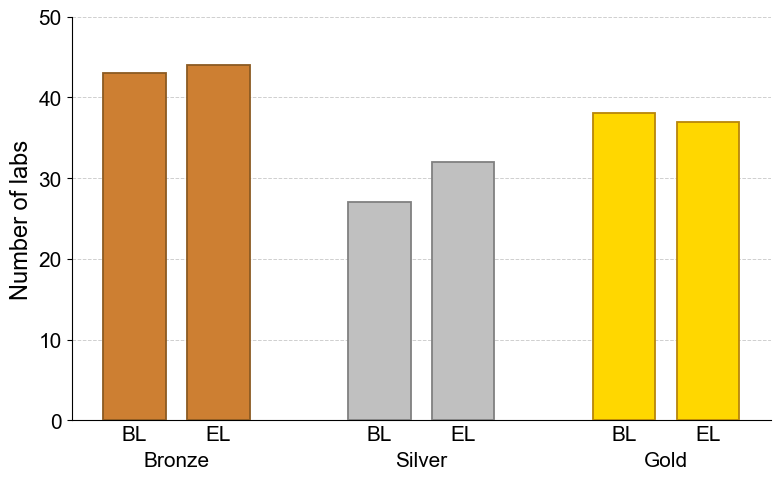

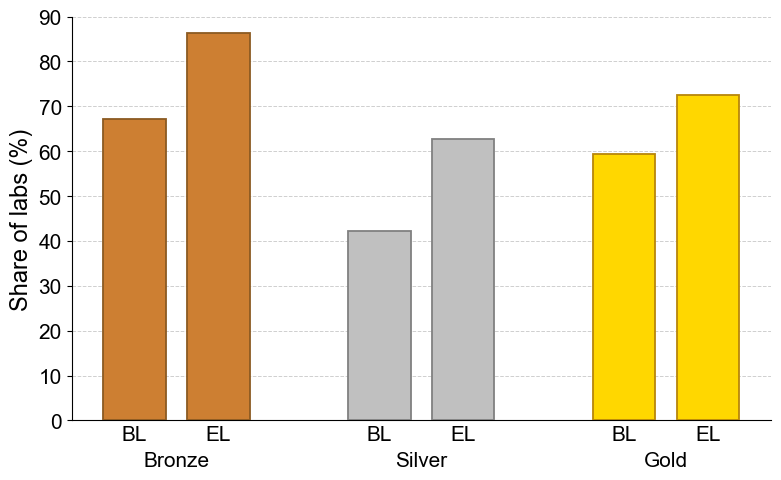

In [5]:

# Colors of bars
cert_levels = ["bronze", "silver", "gold"]
cert_fill   = {"bronze": "#CD7F32", "silver": "#C0C0C0", "gold": "#FFD700"}
cert_edge   = {"bronze": "#8B5A22", "silver": "#808080", "gold": "#B8860B"}

# Bar layout
bar_w     = 0.35
intra_gap = 0.12   # small gap between BL and EL within a group
inter_gap = 0.55   # larger gap between groups
spacing   = bar_w + intra_gap   # distance between bar centres within a group
bl_x      = [i * (2 * bar_w + intra_gap + inter_gap) for i in range(3)]
el_x      = [x + spacing for x in bl_x]
group_ctrs = [(bl_x[i] + el_x[i]) / 2 for i in range(3)]  # true midpoints
all_x      = [x for pair in zip(bl_x, el_x) for x in pair]
all_labels = ["BL", "EL"] * 3

def cert_count(level, wave):
    return int((labs[f"{level}_cert_{wave}"] == "Certified").sum())

def cert_pct(level, wave):
    col = f"{level}_cert_{wave}"
    n = labs[col].notna().sum()
    c = (labs[col] == "Certified").sum()
    return (c / n * 100) if n > 0 else 0

for metric, fn, ylabel, ylim in [
    ("counts",      cert_count, "Number of labs",    (0, 50)),
    ("percentages", cert_pct,   "Share of labs (%)", (0, 90)),
]:
    fig, ax = plt.subplots(figsize=(8, 5))

    for i, lvl in enumerate(cert_levels):
        fc = cert_fill[lvl]
        ec = cert_edge[lvl]
        kw = dict(width=bar_w, edgecolor=ec, linewidth=1.3, zorder=3)
        ax.bar(bl_x[i], fn(lvl, "bl"), color=fc, **kw)
        ax.bar(el_x[i], fn(lvl, "el"), color=fc, **kw)

    # BL / EL tick labels
    ax.set_xticks(all_x)
    ax.set_xticklabels(all_labels, fontsize=tick_label_size, fontfamily=plot_font)
    ax.tick_params(axis="x", length=0)

    # Bronze / Silver / Gold group labels, placed 22 pts below axes bottom
    ax.set_ylim(ylim)
    xform = blended_transform_factory(ax.transData, ax.transAxes)
    for lvl_name, cx in zip(["Bronze", "Silver", "Gold"], group_ctrs):
        ax.annotate(lvl_name, xy=(cx, 0), xycoords=xform,
                    xytext=(0, -22), textcoords="offset points",
                    ha="center", va="top",
                    fontsize=tick_label_size, fontfamily=plot_font)

    ax.set_ylabel(ylabel, fontsize=axis_title_size, fontfamily=plot_font)
    ax.tick_params(axis="y", labelsize=tick_label_size)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()
    fig.savefig(output_folder / f"certification_{metric}.pdf")
    plt.show()


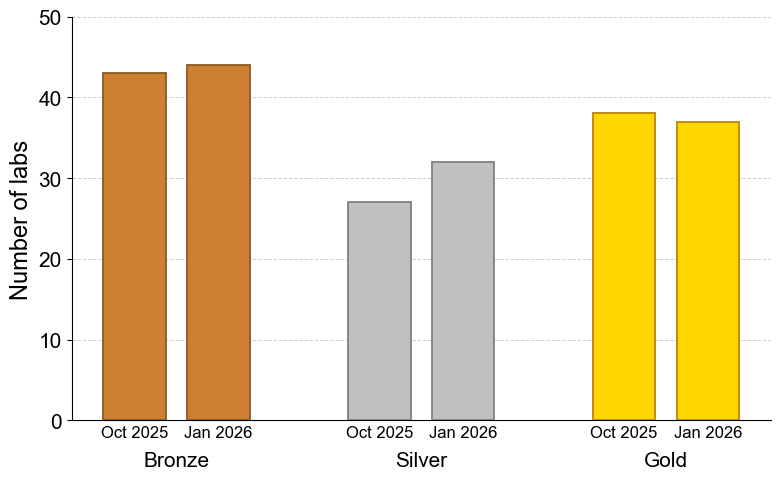

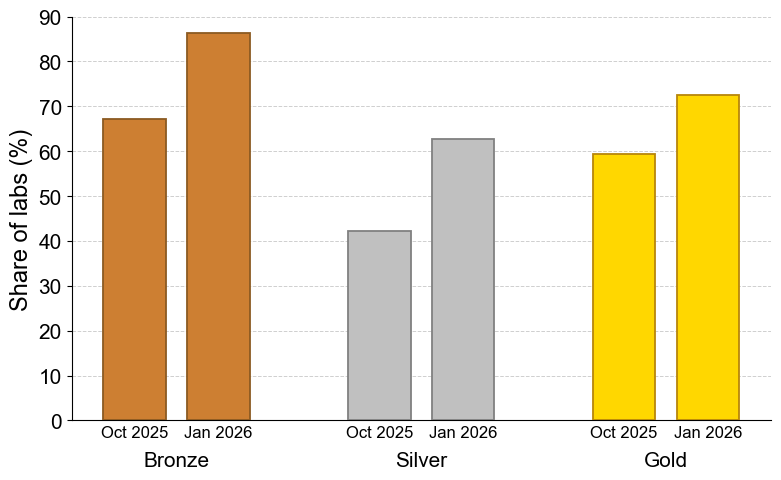

In [6]:
# Suco version: same figures but with "Oct 2025" / "Jan 2026" labels

for metric, fn, ylabel, ylim in [
    ("counts",      cert_count, "Number of labs",    (0, 50)),
    ("percentages", cert_pct,   "Share of labs (%)", (0, 90)),
]:
    fig, ax = plt.subplots(figsize=(8, 5))

    for i, lvl in enumerate(cert_levels):
        fc = cert_fill[lvl]
        ec = cert_edge[lvl]
        kw = dict(width=bar_w, edgecolor=ec, linewidth=1.3, zorder=3)
        ax.bar(bl_x[i], fn(lvl, "bl"), color=fc, **kw)
        ax.bar(el_x[i], fn(lvl, "el"), color=fc, **kw)

    # Oct 2025 / Jan 2026 tick labels
    suco_labels = ["Oct 2025", "Jan 2026"] * 3
    ax.set_xticks(all_x)
    ax.set_xticklabels(suco_labels, fontsize=tick_label_size - 3, fontfamily=plot_font)
    ax.tick_params(axis="x", length=0)

    # Bronze / Silver / Gold group labels
    ax.set_ylim(ylim)
    xform = blended_transform_factory(ax.transData, ax.transAxes)
    for lvl_name, cx in zip(["Bronze", "Silver", "Gold"], group_ctrs):
        ax.annotate(lvl_name, xy=(cx, 0), xycoords=xform,
                    xytext=(0, -22), textcoords="offset points",
                    ha="center", va="top",
                    fontsize=tick_label_size, fontfamily=plot_font)

    ax.set_ylabel(ylabel, fontsize=axis_title_size, fontfamily=plot_font)
    ax.tick_params(axis="y", labelsize=tick_label_size)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()
    fig.savefig(output_folder / f"certification_{metric}_suco.pdf")
    plt.show()
